In [1]:

import numpy as np
import pandas as pd
import pickle
from scipy.stats import entropy
import matplotlib.pyplot as plt
from collections import Counter

# Set random seed for reproducibility
np.random.seed(42)

print("Environment check complete. Loading data files...")


Environment check complete. Loading data files...


In [2]:

# Load the N=10^5 peak data
peaks_N1e5 = pd.read_csv('peaks_zeta_N100000.csv')
print(f"Loaded N=10^5 peaks: {len(peaks_N1e5)} peaks")
print(peaks_N1e5.head())
print(f"\nColumns: {peaks_N1e5.columns.tolist()}")


Loaded N=10^5 peaks: 126 peaks
 t height r
0 182482.482482 24.735630 2.990813
1 186886.886887 22.011001 2.417172
2 184684.684685 21.681075 2.182303
3 172972.972973 16.932401 2.551947
4 163563.563564 16.817055 2.364912

Columns: ['t', 'height', 'r']


In [3]:

# Load the N=10^6 results
with open('detailed_results_N1e6.pkl', 'rb') as f:
 results_N1e6 = pickle.load(f)

print("Keys in detailed_results_N1e6.pkl:")
print(results_N1e6.keys())


Keys in detailed_results_N1e6.pkl:
dict_keys(['zeta', 'f_rand', 'L_mobius'])


In [4]:

# Examine zeta data structure with correct keys
zeta_data = results_N1e6['zeta']
print("Keys in zeta data:")
print(zeta_data.keys())
print(f"\nNumber of peaks at N=10^6: {len(zeta_data['peak_t'])}")
print(f"Peak locations (first 5): {zeta_data['peak_t'][:5]}")
print(f"Peak heights (first 5): {zeta_data['peak_heights'][:5]}")
print(f"r values (first 5): {zeta_data['r_values'][:5]}")


Keys in zeta data:
dict_keys(['magnitudes', 'peak_t', 'peak_heights', 'peak_indices', 'r_values', 'mean_r', 'std_r', 'median_r'])

Number of peaks at N=10^6: 50
Peak locations (first 5): [1948000. 1828000. 1894000. 1734000. 1787000.]
Peak heights (first 5): [20.26291779 17.54511647 16.4788541 16.45057992 15.93424324]
r values (first 5): [3.53246643 3.93381778 1.54153057 0.69932041 2.7271974 ]


In [5]:

# Load omega values
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values = pickle.load(f)

print(f"Omega values array shape: {omega_values.shape}")
print(f"First 20 omega values: {omega_values[:20]}")
print(f"\nNote: omega_values[i] = Ω(i+1) (0-based indexing)")
print(f"For example, omega_values[0] = Ω(1) = {omega_values[0]}")
print(f"omega_values[1] = Ω(2) = {omega_values[1]}")
print(f"omega_values[5] = Ω(6) = Ω(2×3) = {omega_values[5]}")


Omega values array shape: (1000000,)
First 20 omega values: [0 1 1 2 1 2 1 3 2 2 1 3 1 2 2 4 1 3 1 3]

Note: omega_values[i] = Ω(i+1) (0-based indexing)
For example, omega_values[0] = Ω(1) = 0
omega_values[1] = Ω(2) = 1
omega_values[5] = Ω(6) = Ω(2×3) = 2


In [6]:

def kahan_sum(values):
 """
 Kahan compensated summation for high numerical precision.
 Works with complex arrays.
 """
 s = 0.0 + 0.0j if np.iscomplexobj(values) else 0.0
 c = 0.0 + 0.0j if np.iscomplexobj(values) else 0.0
 
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 
 return s

def compute_omega_class_sums(t, N, omega_values, k_max=10):
 """
 Compute ω-class sums S_k for k=1 to k_max for the zeta function.
 
 For zeta: a_n = 1 for all n
 D_F(t; N) = Σ_{n=1}^N 1/n^{1/2+it}
 S_k = Σ_{n: Ω(n)=k} 1/n^{1/2+it}
 
 Parameters:
 -----------
 t : float
 The t-value at which to evaluate
 N : int
 Truncation parameter
 omega_values : array
 Pre-computed Ω(n) values (0-indexed: omega_values[i] = Ω(i+1))
 k_max : int
 Maximum ω-class to compute
 
 Returns:
 --------
 S_k : dict
 Dictionary mapping k -> S_k (complex value)
 """
 S_k = {}
 
 for k in range(1, k_max + 1):
 # Find indices where Ω(n) = k
 # omega_values[i] corresponds to n = i+1
 indices = np.where(omega_values[:N] == k)[0]
 n_values = indices + 1 # Convert from 0-based index to n
 
 if len(n_values) == 0:
 S_k[k] = 0.0 + 0.0j
 continue
 
 # Compute terms: 1/n^{1/2+it} = n^{-1/2} * n^{-it} = n^{-1/2} * e^{-it*log(n)}
 terms = n_values**(-0.5) * np.exp(-1j * t * np.log(n_values))
 
 # Use Kahan summation for precision
 S_k[k] = kahan_sum(terms)
 
 return S_k

# Test the function with first peak from N=10^5
test_t = peaks_N1e5.iloc[0]['t']
test_N = 100000
S_k_test = compute_omega_class_sums(test_t, test_N, omega_values, k_max=10)

print(f"Test computation at t={test_t}, N={test_N}")
print(f"\nω-class sums S_k:")
for k in range(1, 11):
 print(f"k={k}: |S_{k}| = {abs(S_k_test[k]):.6f}")

# Verify total sum matches expected peak height approximately
total_D = sum(S_k_test.values())
print(f"\nTotal |D_F(t; N)| from sum of S_k: {abs(total_D):.6f}")
print(f"Reported peak height: {peaks_N1e5.iloc[0]['height']:.6f}")


Test computation at t=182482.4824824825, N=100000

ω-class sums S_k:
k=1: |S_1| = 2.713777
k=2: |S_2| = 3.510701
k=3: |S_3| = 4.849138
k=4: |S_4| = 4.982522
k=5: |S_5| = 4.136401
k=6: |S_6| = 2.819858
k=7: |S_7| = 1.891291
k=8: |S_8| = 1.174301
k=9: |S_9| = 0.663081
k=10: |S_10| = 0.371271

Total |D_F(t; N)| from sum of S_k: 24.161246
Reported peak height: 24.735630


In [7]:

# Good agreement! Now compute full ω-class decomposition for all N=10^5 peaks
print("Computing ω-class decompositions for N=10^5 peaks...")
N_1e5 = 100000

k_max_N1e5 = [] # Store the dominant ω-class for each peak
P_k_all_N1e5 = [] # Store all power contributions for analysis
Den_all_N1e5 = [] # Store all denominators

for idx, row in peaks_N1e5.iterrows():
 t = row['t']
 
 # Compute ω-class sums
 S_k = compute_omega_class_sums(t, N_1e5, omega_values, k_max=10)
 
 # Compute power contributions P_k = |S_k|²
 P_k = {k: abs(S_k[k])**2 for k in range(1, 11)}
 
 # Total power (denominator)
 Den = sum(P_k.values())
 
 # Find dominant ω-class
 k_dominant = max(P_k.keys(), key=lambda k: P_k[k])
 
 k_max_N1e5.append(k_dominant)
 P_k_all_N1e5.append(P_k)
 Den_all_N1e5.append(Den)
 
 if (idx + 1) % 25 == 0:
 print(f" Processed {idx + 1}/{len(peaks_N1e5)} peaks...")

print(f"\nCompleted N=10^5: {len(k_max_N1e5)} peaks processed")
print(f"Dominant ω-class distribution (first 20): {k_max_N1e5[:20]}")


Computing ω-class decompositions for N=10^5 peaks...


 Processed 25/126 peaks...


 Processed 50/126 peaks...


 Processed 75/126 peaks...


 Processed 100/126 peaks...


 Processed 125/126 peaks...

Completed N=10^5: 126 peaks processed
Dominant ω-class distribution (first 20): [4, 3, 4, 2, 3, 2, 3, 2, 3, 2, 2, 3, 2, 2, 2, 2, 1, 2, 2, 2]


In [8]:

# Now compute for N=10^6 peaks
print("Computing ω-class decompositions for N=10^6 peaks...")
N_1e6 = 1000000

k_max_N1e6 = [] # Store the dominant ω-class for each peak
P_k_all_N1e6 = [] # Store all power contributions for analysis
Den_all_N1e6 = [] # Store all denominators

peak_t_values = zeta_data['peak_t']

for idx, t in enumerate(peak_t_values):
 # Compute ω-class sums
 S_k = compute_omega_class_sums(t, N_1e6, omega_values, k_max=10)
 
 # Compute power contributions P_k = |S_k|²
 P_k = {k: abs(S_k[k])**2 for k in range(1, 11)}
 
 # Total power (denominator)
 Den = sum(P_k.values())
 
 # Find dominant ω-class
 k_dominant = max(P_k.keys(), key=lambda k: P_k[k])
 
 k_max_N1e6.append(k_dominant)
 P_k_all_N1e6.append(P_k)
 Den_all_N1e6.append(Den)
 
 if (idx + 1) % 10 == 0:
 print(f" Processed {idx + 1}/{len(peak_t_values)} peaks...")

print(f"\nCompleted N=10^6: {len(k_max_N1e6)} peaks processed")
print(f"Dominant ω-class distribution (first 20): {k_max_N1e6[:20]}")


Computing ω-class decompositions for N=10^6 peaks...


 Processed 10/50 peaks...


 Processed 20/50 peaks...


 Processed 30/50 peaks...


 Processed 40/50 peaks...


 Processed 50/50 peaks...

Completed N=10^6: 50 peaks processed
Dominant ω-class distribution (first 20): [3, 3, 2, 3, 2, 2, 2, 2, 2, 2, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2]


In [9]:

# Analyze the distributions of dominant ω-classes
from collections import Counter

counter_N1e5 = Counter(k_max_N1e5)
counter_N1e6 = Counter(k_max_N1e6)

print("Distribution of dominant ω-classes at N=10^5:")
print(f"Total peaks: {len(k_max_N1e5)}")
for k in sorted(counter_N1e5.keys()):
 count = counter_N1e5[k]
 percent = 100 * count / len(k_max_N1e5)
 print(f" k={k}: {count} peaks ({percent:.1f}%)")

print("\nDistribution of dominant ω-classes at N=10^6:")
print(f"Total peaks: {len(k_max_N1e6)}")
for k in sorted(counter_N1e6.keys()):
 count = counter_N1e6[k]
 percent = 100 * count / len(k_max_N1e6)
 print(f" k={k}: {count} peaks ({percent:.1f}%)")


Distribution of dominant ω-classes at N=10^5:
Total peaks: 126
 k=1: 55 peaks (43.7%)
 k=2: 55 peaks (43.7%)
 k=3: 11 peaks (8.7%)
 k=4: 5 peaks (4.0%)

Distribution of dominant ω-classes at N=10^6:
Total peaks: 50
 k=1: 8 peaks (16.0%)
 k=2: 34 peaks (68.0%)
 k=3: 7 peaks (14.0%)
 k=4: 1 peaks (2.0%)


In [10]:

# Compute Shannon entropy for both distributions
def shannon_entropy(k_max_list):
 """
 Compute Shannon entropy H = -Σ p_i log2(p_i)
 where p_i is the probability of observing class i
 """
 counter = Counter(k_max_list)
 total = len(k_max_list)
 
 # Get probabilities
 probabilities = np.array([counter[k] / total for k in counter.keys()])
 
 # Compute Shannon entropy
 H = -np.sum(probabilities * np.log2(probabilities))
 
 return H

# Compute entropies
H_N1e5 = shannon_entropy(k_max_N1e5)
H_N1e6 = shannon_entropy(k_max_N1e6)

print(f"Shannon entropy of dominant ω-class distribution:")
print(f" N=10^5: H = {H_N1e5:.4f} bits")
print(f" N=10^6: H = {H_N1e6:.4f} bits")
print(f" Difference: ΔH = {H_N1e6 - H_N1e5:.4f} bits")

if H_N1e6 > H_N1e5:
 print(f"\nN=10^6 has HIGHER entropy (more diverse distribution)")
else:
 print(f"\nN=10^5 has HIGHER entropy (more diverse distribution)")


Shannon entropy of dominant ω-class distribution:
 N=10^5: H = 1.5359 bits
 N=10^6: H = 1.3114 bits
 Difference: ΔH = -0.2246 bits

N=10^5 has HIGHER entropy (more diverse distribution)


In [11]:

# This is surprising - let's analyze the variance of Den to understand better
Den_N1e5 = np.array(Den_all_N1e5)
Den_N1e6 = np.array(Den_all_N1e6)

print("Denominator (Den = Σ_k|S_k|²) statistics:")
print(f"\nN=10^5:")
print(f" Mean: {np.mean(Den_N1e5):.4f}")
print(f" Std Dev: {np.std(Den_N1e5):.4f}")
print(f" Coefficient of Variation (CV): {np.std(Den_N1e5)/np.mean(Den_N1e5):.4f}")
print(f" Min: {np.min(Den_N1e5):.4f}")
print(f" Max: {np.max(Den_N1e5):.4f}")
print(f" Range: {np.max(Den_N1e5) - np.min(Den_N1e5):.4f}")

print(f"\nN=10^6:")
print(f" Mean: {np.mean(Den_N1e6):.4f}")
print(f" Std Dev: {np.std(Den_N1e6):.4f}")
print(f" Coefficient of Variation (CV): {np.std(Den_N1e6)/np.mean(Den_N1e6):.4f}")
print(f" Min: {np.min(Den_N1e6):.4f}")
print(f" Max: {np.max(Den_N1e6):.4f}")
print(f" Range: {np.max(Den_N1e6) - np.min(Den_N1e6):.4f}")

print(f"\nVariance increase from N=10^5 to N=10^6:")
var_ratio = np.var(Den_N1e6) / np.var(Den_N1e5)
std_ratio = np.std(Den_N1e6) / np.std(Den_N1e5)
print(f" Variance ratio: {var_ratio:.4f}")
print(f" Std dev ratio: {std_ratio:.4f}")


Denominator (Den = Σ_k|S_k|²) statistics:

N=10^5:
 Mean: 17.0261
 Std Dev: 19.4996
 Coefficient of Variation (CV): 1.1453
 Min: 0.7057
 Max: 98.6242
 Range: 97.9185

N=10^6:
 Mean: 39.2273
 Std Dev: 37.4714
 Coefficient of Variation (CV): 0.9552
 Min: 7.5725
 Max: 203.8047
 Range: 196.2323

Variance increase from N=10^5 to N=10^6:
 Variance ratio: 3.6927
 Std dev ratio: 1.9216


In [12]:

# The variance indeed increased significantly! But entropy decreased.
# Let's analyze the power distribution more carefully
# Perhaps the issue is that at N=10^6, one class (k=2) dominates MORE strongly,
# but the magnitude of its contributions varies more

# Compute the fraction of total power contributed by the dominant class
frac_dominant_N1e5 = []
for i, k_dom in enumerate(k_max_N1e5):
 P_k = P_k_all_N1e5[i]
 Den = Den_all_N1e5[i]
 frac_dominant_N1e5.append(P_k[k_dom] / Den)

frac_dominant_N1e6 = []
for i, k_dom in enumerate(k_max_N1e6):
 P_k = P_k_all_N1e6[i]
 Den = Den_all_N1e6[i]
 frac_dominant_N1e6.append(P_k[k_dom] / Den)

print("Fraction of total power from dominant ω-class:")
print(f"\nN=10^5:")
print(f" Mean: {np.mean(frac_dominant_N1e5):.4f}")
print(f" Std Dev: {np.std(frac_dominant_N1e5):.4f}")
print(f" Min: {np.min(frac_dominant_N1e5):.4f}")
print(f" Max: {np.max(frac_dominant_N1e5):.4f}")

print(f"\nN=10^6:")
print(f" Mean: {np.mean(frac_dominant_N1e6):.4f}")
print(f" Std Dev: {np.std(frac_dominant_N1e6):.4f}")
print(f" Min: {np.min(frac_dominant_N1e6):.4f}")
print(f" Max: {np.max(frac_dominant_N1e6):.4f}")


Fraction of total power from dominant ω-class:

N=10^5:
 Mean: 0.4419
 Std Dev: 0.1410
 Min: 0.2221
 Max: 0.8709

N=10^6:
 Mean: 0.3393
 Std Dev: 0.0651
 Min: 0.2253
 Max: 0.4940


In [13]:

# Interesting! At N=10^6, the dominant class contributes a SMALLER fraction
# This suggests the power is more evenly distributed across classes
# Let's use the effective number of classes (inverse participation ratio)

def effective_number_of_classes(P_k_dict):
 """
 Compute the effective number of classes using the inverse participation ratio.
 N_eff = (Σ_k P_k²)^(-1) / (Σ_k P_k)²
 Equivalently: N_eff = 1 / Σ_k (P_k / Σ P_k)²
 """
 P_values = np.array(list(P_k_dict.values()))
 total = np.sum(P_values)
 normalized = P_values / total
 return 1.0 / np.sum(normalized**2)

N_eff_N1e5 = [effective_number_of_classes(P_k) for P_k in P_k_all_N1e5]
N_eff_N1e6 = [effective_number_of_classes(P_k) for P_k in P_k_all_N1e6]

print("Effective number of contributing ω-classes (N_eff):")
print(f"\nN=10^5:")
print(f" Mean: {np.mean(N_eff_N1e5):.4f}")
print(f" Std Dev: {np.std(N_eff_N1e5):.4f}")
print(f" Min: {np.min(N_eff_N1e5):.4f}")
print(f" Max: {np.max(N_eff_N1e5):.4f}")

print(f"\nN=10^6:")
print(f" Mean: {np.mean(N_eff_N1e6):.4f}")
print(f" Std Dev: {np.std(N_eff_N1e6):.4f}")
print(f" Min: {np.min(N_eff_N1e6):.4f}")
print(f" Max: {np.max(N_eff_N1e6):.4f}")

print(f"\nIncrease in mean N_eff: {np.mean(N_eff_N1e6) - np.mean(N_eff_N1e5):.4f}")
print(f"Relative increase: {(np.mean(N_eff_N1e6) / np.mean(N_eff_N1e5) - 1) * 100:.2f}%")


Effective number of contributing ω-classes (N_eff):

N=10^5:
 Mean: 3.4123
 Std Dev: 1.1289
 Min: 1.3032
 Max: 5.8772

N=10^6:
 Mean: 4.2424
 Std Dev: 0.7807
 Min: 2.7964
 Max: 6.1033

Increase in mean N_eff: 0.8301
Relative increase: 24.33%


In [14]:

# Excellent! This is the key insight. At N=10^6, the power is more evenly distributed
# across multiple ω-classes (N_eff increases by 24%), meaning no single class dominates
# as strongly. This creates MORE DIVERSITY in the power distribution across the 10 classes.

# Let's compute the Shannon entropy of the full power distribution (all 10 classes)
# for each peak, then compare the mean and variance of these entropies

def power_distribution_entropy(P_k_dict):
 """
 Compute Shannon entropy of the power distribution across all ω-classes.
 H = -Σ_k (P_k / Σ P_k) log2(P_k / Σ P_k)
 """
 P_values = np.array(list(P_k_dict.values()))
 total = np.sum(P_values)
 normalized = P_values / total
 # Remove zero probabilities to avoid log(0)
 normalized = normalized[normalized > 0]
 return -np.sum(normalized * np.log2(normalized))

H_dist_N1e5 = [power_distribution_entropy(P_k) for P_k in P_k_all_N1e5]
H_dist_N1e6 = [power_distribution_entropy(P_k) for P_k in P_k_all_N1e6]

print("Shannon entropy of power distribution across ω-classes (within each peak):")
print(f"\nN=10^5:")
print(f" Mean: {np.mean(H_dist_N1e5):.4f} bits")
print(f" Std Dev: {np.std(H_dist_N1e5):.4f} bits")
print(f" Min: {np.min(H_dist_N1e5):.4f} bits")
print(f" Max: {np.max(H_dist_N1e5):.4f} bits")

print(f"\nN=10^6:")
print(f" Mean: {np.mean(H_dist_N1e6):.4f} bits")
print(f" Std Dev: {np.std(H_dist_N1e6):.4f} bits")
print(f" Min: {np.min(H_dist_N1e6):.4f} bits")
print(f" Max: {np.max(H_dist_N1e6):.4f} bits")

print(f"\nIncrease in mean entropy: {np.mean(H_dist_N1e6) - np.mean(H_dist_N1e5):.4f} bits")
print(f"Increase in entropy variance: {np.var(H_dist_N1e6) - np.var(H_dist_N1e5):.4f}")


Shannon entropy of power distribution across ω-classes (within each peak):

N=10^5:
 Mean: 1.9692 bits
 Std Dev: 0.4496 bits
 Min: 0.7438 bits
 Max: 2.7842 bits

N=10^6:
 Mean: 2.2852 bits
 Std Dev: 0.2456 bits
 Min: 1.7174 bits
 Max: 2.7770 bits

Increase in mean entropy: 0.3160 bits
Increase in entropy variance: -0.1418


In [15]:

# Perfect! The within-peak power distribution entropy INCREASES at N=10^6
# AND the variance of this entropy DECREASES

# This means:
# 1. At N=10^6, peaks have more evenly distributed power across ω-classes (higher mean H)
# 2. The peaks are more CONSISTENT in this behavior (lower variance in H)

# Now let's analyze variance of Den in relation to the diversity of power distribution
# The hypothesis was that increased variance of Den is due to more diverse k_max
# But we found the opposite: k_max is LESS diverse (lower entropy of k_max distribution)
# However, within each peak, the power is MORE diverse (higher entropy of P_k distribution)

# Let's examine correlation between Den and the entropy of power distribution
import scipy.stats as stats

corr_N1e5, p_N1e5 = stats.pearsonr(Den_N1e5, H_dist_N1e5)
corr_N1e6, p_N1e6 = stats.pearsonr(Den_N1e6, H_dist_N1e6)

print("Correlation between Den and entropy of power distribution:")
print(f"\nN=10^5:")
print(f" Pearson r: {corr_N1e5:.4f}")
print(f" p-value: {p_N1e5:.4e}")

print(f"\nN=10^6:")
print(f" Pearson r: {corr_N1e6:.4f}")
print(f" p-value: {p_N1e6:.4e}")


Correlation between Den and entropy of power distribution:

N=10^5:
 Pearson r: 0.6008
 p-value: 1.0281e-13

N=10^6:
 Pearson r: 0.4122
 p-value: 2.9352e-03


In [16]:

# Let's examine the variance of individual P_k values across peaks
# to see which ω-classes contribute most to the variance in Den

print("Variance of P_k across peaks for each ω-class:")
print("\nN=10^5:")
for k in range(1, 11):
 P_k_values = [P_k_all_N1e5[i][k] for i in range(len(P_k_all_N1e5))]
 var_k = np.var(P_k_values)
 mean_k = np.mean(P_k_values)
 print(f" k={k}: mean={mean_k:6.3f}, var={var_k:8.3f}, CV={np.sqrt(var_k)/mean_k:.3f}")

print("\nN=10^6:")
for k in range(1, 11):
 P_k_values = [P_k_all_N1e6[i][k] for i in range(len(P_k_all_N1e6))]
 var_k = np.var(P_k_values)
 mean_k = np.mean(P_k_values)
 print(f" k={k}: mean={mean_k:6.3f}, var={var_k:8.3f}, CV={np.sqrt(var_k)/mean_k:.3f}")


Variance of P_k across peaks for each ω-class:

N=10^5:
 k=1: mean= 3.779, var= 6.159, CV=0.657
 k=2: mean= 5.136, var= 27.815, CV=1.027
 k=3: mean= 3.713, var= 29.340, CV=1.459
 k=4: mean= 2.252, var= 15.071, CV=1.724
 k=5: mean= 1.183, var= 5.646, CV=2.008
 k=6: mean= 0.550, var= 1.334, CV=2.100
 k=7: mean= 0.248, var= 0.298, CV=2.205
 k=8: mean= 0.104, var= 0.052, CV=2.195
 k=9: mean= 0.043, var= 0.007, CV=2.014
 k=10: mean= 0.018, var= 0.001, CV=1.912

N=10^6:
 k=1: mean= 6.054, var= 4.786, CV=0.361
 k=2: mean=10.948, var= 57.700, CV=0.694
 k=3: mean= 9.624, var= 96.022, CV=1.018
 k=4: mean= 6.634, var= 91.017, CV=1.438
 k=5: mean= 3.387, var= 41.573, CV=1.904
 k=6: mean= 1.554, var= 12.241, CV=2.252
 k=7: mean= 0.641, var= 2.295, CV=2.364
 k=8: mean= 0.248, var= 0.345, CV=2.373
 k=9: mean= 0.097, var= 0.047, CV=2.245
 k=10: mean= 0.041, var= 0.007, CV=2.057


In [17]:

# Calculate the contribution of each ω-class to the total variance in Den
# Using the fact that Var(Den) = Var(Σ P_k) = Σ Var(P_k) + 2 Σ_{i<j} Cov(P_i, P_j)

# First, let's compute the total variance contribution from each class
print("Contribution to variance of Den from each ω-class:")
print("\nN=10^5:")
total_var_N1e5 = np.var(Den_N1e5)
for k in range(1, 11):
 P_k_values = [P_k_all_N1e5[i][k] for i in range(len(P_k_all_N1e5))]
 var_k = np.var(P_k_values)
 contribution = var_k / total_var_N1e5 * 100
 print(f" k={k}: var={var_k:8.3f}, contribution to Var(Den): {contribution:5.2f}%")

print(f"\nTotal Var(Den) at N=10^5: {total_var_N1e5:.3f}")

print("\n" + "="*60)
print("\nN=10^6:")
total_var_N1e6 = np.var(Den_N1e6)
for k in range(1, 11):
 P_k_values = [P_k_all_N1e6[i][k] for i in range(len(P_k_all_N1e6))]
 var_k = np.var(P_k_values)
 contribution = var_k / total_var_N1e6 * 100
 print(f" k={k}: var={var_k:8.3f}, contribution to Var(Den): {contribution:5.2f}%")

print(f"\nTotal Var(Den) at N=10^6: {total_var_N1e6:.3f}")

# Note: contributions sum to less than 100% because we're ignoring covariance terms


Contribution to variance of Den from each ω-class:

N=10^5:
 k=1: var= 6.159, contribution to Var(Den): 1.62%
 k=2: var= 27.815, contribution to Var(Den): 7.32%
 k=3: var= 29.340, contribution to Var(Den): 7.72%
 k=4: var= 15.071, contribution to Var(Den): 3.96%
 k=5: var= 5.646, contribution to Var(Den): 1.48%
 k=6: var= 1.334, contribution to Var(Den): 0.35%
 k=7: var= 0.298, contribution to Var(Den): 0.08%
 k=8: var= 0.052, contribution to Var(Den): 0.01%
 k=9: var= 0.007, contribution to Var(Den): 0.00%
 k=10: var= 0.001, contribution to Var(Den): 0.00%

Total Var(Den) at N=10^5: 380.234


N=10^6:
 k=1: var= 4.786, contribution to Var(Den): 0.34%
 k=2: var= 57.700, contribution to Var(Den): 4.11%
 k=3: var= 96.022, contribution to Var(Den): 6.84%
 k=4: var= 91.017, contribution to Var(Den): 6.48%
 k=5: var= 41.573, contribution to Var(Den): 2.96%
 k=6: var= 12.241, contribution to Var(Den): 0.87%
 k=7: var= 2.295, contribution to Var(Den): 0.16%
 k=8: var= 0.345, contribution to Va

In [18]:

# The individual variances only account for ~23% at N=10^5 and ~22% at N=10^6
# This means covariance terms are very important!

# Let's compute the full covariance matrix
import pandas as pd

def compute_covariance_contributions(P_k_all):
 """
 Compute covariance matrix and contributions to Var(Den)
 """
 n_peaks = len(P_k_all)
 n_classes = 10
 
 # Create matrix of P_k values: rows = peaks, cols = classes
 P_matrix = np.zeros((n_peaks, n_classes))
 for i in range(n_peaks):
 for k in range(1, n_classes + 1):
 P_matrix[i, k-1] = P_k_all[i][k]
 
 # Compute covariance matrix
 cov_matrix = np.cov(P_matrix, rowvar=False)
 
 # Variance of Den = sum of all elements in covariance matrix
 var_den_from_cov = np.sum(cov_matrix)
 
 return cov_matrix, var_den_from_cov, P_matrix

cov_N1e5, var_den_cov_N1e5, P_matrix_N1e5 = compute_covariance_contributions(P_k_all_N1e5)
cov_N1e6, var_den_cov_N1e6, P_matrix_N1e6 = compute_covariance_contributions(P_k_all_N1e6)

print("Variance of Den from covariance matrix approach:")
print(f"N=10^5: {var_den_cov_N1e5:.3f} (direct: {np.var(Den_N1e5):.3f})")
print(f"N=10^6: {var_den_cov_N1e6:.3f} (direct: {np.var(Den_N1e6):.3f})")
print("\nExcellent agreement!")


Variance of Den from covariance matrix approach:
N=10^5: 383.276 (direct: 380.234)
N=10^6: 1432.758 (direct: 1404.103)

Excellent agreement!


In [19]:

# Now compute the contribution from diagonal (variances) vs off-diagonal (covariances)
diag_contribution_N1e5 = np.sum(np.diag(cov_N1e5))
offdiag_contribution_N1e5 = np.sum(cov_N1e5) - diag_contribution_N1e5

diag_contribution_N1e6 = np.sum(np.diag(cov_N1e6))
offdiag_contribution_N1e6 = np.sum(cov_N1e6) - diag_contribution_N1e6

print("Decomposition of Var(Den):")
print("\nN=10^5:")
print(f" Diagonal (Σ Var(P_k)): {diag_contribution_N1e5:8.3f} ({diag_contribution_N1e5/var_den_cov_N1e5*100:5.2f}%)")
print(f" Off-diagonal (2Σ Cov(P_i,P_j)): {offdiag_contribution_N1e5:8.3f} ({offdiag_contribution_N1e5/var_den_cov_N1e5*100:5.2f}%)")
print(f" Total: {var_den_cov_N1e5:8.3f}")

print("\nN=10^6:")
print(f" Diagonal (Σ Var(P_k)): {diag_contribution_N1e6:8.3f} ({diag_contribution_N1e6/var_den_cov_N1e6*100:5.2f}%)")
print(f" Off-diagonal (2Σ Cov(P_i,P_j)): {offdiag_contribution_N1e6:8.3f} ({offdiag_contribution_N1e6/var_den_cov_N1e6*100:5.2f}%)")
print(f" Total: {var_den_cov_N1e6:8.3f}")

print("\nChange from N=10^5 to N=10^6:")
print(f" Δ Diagonal: {diag_contribution_N1e6 - diag_contribution_N1e5:8.3f}")
print(f" Δ Off-diagonal: {offdiag_contribution_N1e6 - offdiag_contribution_N1e5:8.3f}")
print(f" Δ Total: {var_den_cov_N1e6 - var_den_cov_N1e5:8.3f}")


Decomposition of Var(Den):

N=10^5:
 Diagonal (Σ Var(P_k)): 86.409 (22.54%)
 Off-diagonal (2Σ Cov(P_i,P_j)): 296.867 (77.46%)
 Total: 383.276

N=10^6:
 Diagonal (Σ Var(P_k)): 312.280 (21.80%)
 Off-diagonal (2Σ Cov(P_i,P_j)): 1120.478 (78.20%)
 Total: 1432.758

Change from N=10^5 to N=10^6:
 Δ Diagonal: 225.871
 Δ Off-diagonal: 823.612
 Δ Total: 1049.482


In [20]:

# The off-diagonal covariances dominate and contribute 78% of total variance at both scales
# The increase in variance is 78% due to covariances and 22% due to individual variances

# Let's look at the strongest covariances
print("Top 15 covariance pairs at N=10^5:")
cov_pairs_N1e5 = []
for i in range(10):
 for j in range(i+1, 10):
 cov_pairs_N1e5.append((i+1, j+1, cov_N1e5[i, j]))
cov_pairs_N1e5.sort(key=lambda x: abs(x[2]), reverse=True)

for k1, k2, cov_val in cov_pairs_N1e5[:15]:
 contribution = 2 * cov_val / var_den_cov_N1e5 * 100
 print(f" Cov(P_{k1}, P_{k2}): {cov_val:8.3f}, contribution: {contribution:6.2f}%")

print("\n" + "="*60)
print("\nTop 15 covariance pairs at N=10^6:")
cov_pairs_N1e6 = []
for i in range(10):
 for j in range(i+1, 10):
 cov_pairs_N1e6.append((i+1, j+1, cov_N1e6[i, j]))
cov_pairs_N1e6.sort(key=lambda x: abs(x[2]), reverse=True)

for k1, k2, cov_val in cov_pairs_N1e6[:15]:
 contribution = 2 * cov_val / var_den_cov_N1e6 * 100
 print(f" Cov(P_{k1}, P_{k2}): {cov_val:8.3f}, contribution: {contribution:6.2f}%")


Top 15 covariance pairs at N=10^5:
 Cov(P_2, P_3): 25.457, contribution: 13.28%
 Cov(P_3, P_4): 19.464, contribution: 10.16%
 Cov(P_2, P_4): 14.992, contribution: 7.82%
 Cov(P_1, P_2): 11.624, contribution: 6.07%
 Cov(P_3, P_5): 10.830, contribution: 5.65%
 Cov(P_1, P_3): 9.821, contribution: 5.13%
 Cov(P_4, P_5): 8.948, contribution: 4.67%
 Cov(P_2, P_5): 8.058, contribution: 4.20%
 Cov(P_1, P_4): 5.830, contribution: 3.04%
 Cov(P_3, P_6): 4.986, contribution: 2.60%
 Cov(P_4, P_6): 4.121, contribution: 2.15%
 Cov(P_2, P_6): 3.752, contribution: 1.96%
 Cov(P_1, P_5): 3.089, contribution: 1.61%
 Cov(P_5, P_6): 2.672, contribution: 1.39%
 Cov(P_3, P_7): 2.188, contribution: 1.14%


Top 15 covariance pairs at N=10^6:
 Cov(P_3, P_4): 88.627, contribution: 12.37%
 Cov(P_2, P_3): 64.496, contribution: 9.00%
 Cov(P_4, P_5): 60.814, contribution: 8.49%
 Cov(P_3, P_5): 54.285, contribution: 7.58%
 Cov(P_2, P_4): 48.958, contribution: 6.83%
 Cov(P_4, P_6): 31.992, contribution: 4.47%
 Cov(P_3, P

In [21]:

# Very interesting! At N=10^6, the strongest covariances shift to higher k values
# At N=10^5: top covariance is Cov(P_2, P_3) at 13.28%
# At N=10^6: top covariance is Cov(P_3, P_4) at 12.37%

# Let's compute correlation matrices to see the structure more clearly
corr_N1e5 = np.corrcoef(P_matrix_N1e5, rowvar=False)
corr_N1e6 = np.corrcoef(P_matrix_N1e6, rowvar=False)

print("Correlation matrix at N=10^5:")
print(" ", end="")
for k in range(1, 11):
 print(f" k={k}", end="")
print()
for i in range(10):
 print(f"k={i+1:2d}", end="")
 for j in range(10):
 print(f" {corr_N1e5[i, j]:5.3f}", end="")
 print()

print("\n" + "="*70)
print("\nCorrelation matrix at N=10^6:")
print(" ", end="")
for k in range(1, 11):
 print(f" k={k}", end="")
print()
for i in range(10):
 print(f"k={i+1:2d}", end="")
 for j in range(10):
 print(f" {corr_N1e6[i, j]:5.3f}", end="")
 print()


Correlation matrix at N=10^5:
 k=1 k=2 k=3 k=4 k=5 k=6 k=7 k=8 k=9 k=10
k= 1 1.000 0.881 0.725 0.600 0.520 0.499 0.470 0.445 0.472 0.488
k= 2 0.881 1.000 0.884 0.726 0.638 0.611 0.580 0.557 0.592 0.613
k= 3 0.725 0.884 1.000 0.918 0.835 0.791 0.734 0.696 0.702 0.710
k= 4 0.600 0.726 0.918 1.000 0.962 0.912 0.853 0.811 0.787 0.768
k= 5 0.520 0.638 0.835 0.962 1.000 0.966 0.919 0.883 0.841 0.803
k= 6 0.499 0.611 0.791 0.912 0.966 1.000 0.981 0.949 0.904 0.867
k= 7 0.470 0.580 0.734 0.853 0.919 0.981 1.000 0.984 0.952 0.919
k= 8 0.445 0.557 0.696 0.811 0.883 0.949 0.984 1.000 0.978 0.948
k= 9 0.472 0.592 0.702 0.787 0.841 0.904 0.952 0.978 1.000 0.986
k=10 0.488 0.613 0.710 0.768 0.803 0.867 0.919 0.948 0.986 1.000


Correlation matrix at N=10^6:
 k=1 k=2 k=3 k=4 k=5 k=6 k=7 k=8 k=9 k=10
k= 1 1.000 0.854 0.670 0.482 0.375 0.308 0.304 0.281 0.294 0.303
k= 2 0.854 1.000 0.849 0.662 0.531 0.448 0.435 0.407 0.414 0.435
k= 3 0.670 0.849 1.000 0.929 0.842 0.785 0.772 0.746 0.735 0.747
k= 4 0.48

In [22]:

# Fascinating! The correlation structure shows very high correlations between adjacent classes
# especially for higher k values. The correlations are even stronger at N=10^6 for k≥5

# Let's quantify the "diversity" in a different way: compute the variance of the 
# correlation strengths for each scale

# Average correlation (off-diagonal only)
off_diag_mask = ~np.eye(10, dtype=bool)
avg_corr_N1e5 = np.mean(corr_N1e5[off_diag_mask])
avg_corr_N1e6 = np.mean(corr_N1e6[off_diag_mask])

print("Average off-diagonal correlation:")
print(f" N=10^5: {avg_corr_N1e5:.4f}")
print(f" N=10^6: {avg_corr_N1e6:.4f}")

# Look at the spread of dominant class contributions more carefully
# Let's analyze the diversity by looking at which k values appear most frequently
# across the TOP contributing classes (not just the dominant one)

def top_k_contributors(P_k_dict, top_n=3):
 """
 Return the top N contributing ω-classes (by P_k value)
 """
 sorted_classes = sorted(P_k_dict.keys(), key=lambda k: P_k_dict[k], reverse=True)
 return sorted_classes[:top_n]

# Get top 3 contributors for each peak
top3_N1e5 = [top_k_contributors(P_k, top_n=3) for P_k in P_k_all_N1e5]
top3_N1e6 = [top_k_contributors(P_k, top_n=3) for P_k in P_k_all_N1e6]

# Flatten and count
from collections import Counter
all_top3_N1e5 = [k for peak_top3 in top3_N1e5 for k in peak_top3]
all_top3_N1e6 = [k for peak_top3 in top3_N1e6 for k in peak_top3]

counter_top3_N1e5 = Counter(all_top3_N1e5)
counter_top3_N1e6 = Counter(all_top3_N1e6)

print("\nDistribution of ω-classes in top-3 contributors:")
print("\nN=10^5 (total appearances: {})".format(len(all_top3_N1e5)))
for k in sorted(counter_top3_N1e5.keys()):
 count = counter_top3_N1e5[k]
 percent = 100 * count / len(all_top3_N1e5)
 print(f" k={k}: {count} appearances ({percent:.1f}%)")

print("\nN=10^6 (total appearances: {})".format(len(all_top3_N1e6)))
for k in sorted(counter_top3_N1e6.keys()):
 count = counter_top3_N1e6[k]
 percent = 100 * count / len(all_top3_N1e6)
 print(f" k={k}: {count} appearances ({percent:.1f}%)")


Average off-diagonal correlation:
 N=10^5: 0.7702
 N=10^6: 0.7522

Distribution of ω-classes in top-3 contributors:

N=10^5 (total appearances: 378)
 k=1: 110 appearances (29.1%)
 k=2: 115 appearances (30.4%)
 k=3: 105 appearances (27.8%)
 k=4: 37 appearances (9.8%)
 k=5: 8 appearances (2.1%)
 k=6: 3 appearances (0.8%)

N=10^6 (total appearances: 150)
 k=1: 34 appearances (22.7%)
 k=2: 47 appearances (31.3%)
 k=3: 46 appearances (30.7%)
 k=4: 21 appearances (14.0%)
 k=5: 2 appearances (1.3%)


In [23]:

# Compute Shannon entropy of top-3 distribution
H_top3_N1e5 = shannon_entropy(all_top3_N1e5)
H_top3_N1e6 = shannon_entropy(all_top3_N1e6)

print("Shannon entropy of top-3 contributor distribution:")
print(f" N=10^5: H = {H_top3_N1e5:.4f} bits")
print(f" N=10^6: H = {H_top3_N1e6:.4f} bits")
print(f" Difference: ΔH = {H_top3_N1e6 - H_top3_N1e5:.4f} bits")

# Now let's examine the variance structure more directly
# Compute the contribution to Var(Den) from each k-range
print("\n" + "="*70)
print("\nSummary of variance contributions by ω-class range:")
print("\nN=10^5:")
var_k123 = sum([np.var([P_k_all_N1e5[i][k] for i in range(len(P_k_all_N1e5))]) for k in [1,2,3]])
var_k456 = sum([np.var([P_k_all_N1e5[i][k] for i in range(len(P_k_all_N1e5))]) for k in [4,5,6]])
var_k7plus = sum([np.var([P_k_all_N1e5[i][k] for i in range(len(P_k_all_N1e5))]) for k in range(7,11)])
print(f" k∈[1,2,3]: var = {var_k123:.3f} ({var_k123/diag_contribution_N1e5*100:.1f}% of diagonal)")
print(f" k∈[4,5,6]: var = {var_k456:.3f} ({var_k456/diag_contribution_N1e5*100:.1f}% of diagonal)")
print(f" k∈[7,8,9,10]: var = {var_k7plus:.3f} ({var_k7plus/diag_contribution_N1e5*100:.1f}% of diagonal)")

print("\nN=10^6:")
var_k123 = sum([np.var([P_k_all_N1e6[i][k] for i in range(len(P_k_all_N1e6))]) for k in [1,2,3]])
var_k456 = sum([np.var([P_k_all_N1e6[i][k] for i in range(len(P_k_all_N1e6))]) for k in [4,5,6]])
var_k7plus = sum([np.var([P_k_all_N1e6[i][k] for i in range(len(P_k_all_N1e6))]) for k in range(7,11)])
print(f" k∈[1,2,3]: var = {var_k123:.3f} ({var_k123/diag_contribution_N1e6*100:.1f}% of diagonal)")
print(f" k∈[4,5,6]: var = {var_k456:.3f} ({var_k456/diag_contribution_N1e6*100:.1f}% of diagonal)")
print(f" k∈[7,8,9,10]: var = {var_k7plus:.3f} ({var_k7plus/diag_contribution_N1e6*100:.1f}% of diagonal)")


Shannon entropy of top-3 contributor distribution:
 N=10^5: H = 2.0551 bits
 N=10^6: H = 2.0131 bits
 Difference: ΔH = -0.0421 bits


Summary of variance contributions by ω-class range:

N=10^5:
 k∈[1,2,3]: var = 63.314 (73.3% of diagonal)
 k∈[4,5,6]: var = 22.051 (25.5% of diagonal)
 k∈[7,8,9,10]: var = 0.358 (0.4% of diagonal)

N=10^6:
 k∈[1,2,3]: var = 158.508 (50.8% of diagonal)
 k∈[4,5,6]: var = 144.831 (46.4% of diagonal)
 k∈[7,8,9,10]: var = 2.695 (0.9% of diagonal)


In [24]:

# KEY INSIGHT! At N=10^6, the variance contributions shift significantly:
# - k∈[1,2,3] drops from 73.3% to 50.8%
# - k∈[4,5,6] increases from 25.5% to 46.4%
# This is a major redistribution of variance contribution to higher ω-classes!

# Let's compute a "diversity index" based on how evenly variance is distributed
# across the different k-ranges

def variance_distribution_entropy(var_contributions):
 """
 Compute entropy of how variance is distributed across different sources
 """
 total = sum(var_contributions)
 probs = [v/total for v in var_contributions]
 return -sum(p * np.log2(p) for p in probs if p > 0)

# For N=10^5
var_contribs_N1e5 = []
for k in range(1, 11):
 P_k_values = [P_k_all_N1e5[i][k] for i in range(len(P_k_all_N1e5))]
 var_contribs_N1e5.append(np.var(P_k_values))

H_var_N1e5 = variance_distribution_entropy(var_contribs_N1e5)

# For N=10^6
var_contribs_N1e6 = []
for k in range(1, 11):
 P_k_values = [P_k_all_N1e6[i][k] for i in range(len(P_k_all_N1e6))]
 var_contribs_N1e6.append(np.var(P_k_values))

H_var_N1e6 = variance_distribution_entropy(var_contribs_N1e6)

print("Shannon entropy of variance distribution across ω-classes:")
print(f" N=10^5: H = {H_var_N1e5:.4f} bits")
print(f" N=10^6: H = {H_var_N1e6:.4f} bits")
print(f" Difference: ΔH = {H_var_N1e6 - H_var_N1e5:.4f} bits")

if H_var_N1e6 > H_var_N1e5:
 print(f"\n✓ Variance contributions are MORE DIVERSE at N=10^6")
 print(f" This indicates that more ω-classes contribute significantly to Var(Den)")
else:
 print(f"\n✗ Variance contributions are LESS diverse at N=10^6")


Shannon entropy of variance distribution across ω-classes:
 N=10^5: H = 2.1583 bits
 N=10^6: H = 2.2359 bits
 Difference: ΔH = 0.0776 bits

✓ Variance contributions are MORE DIVERSE at N=10^6
 This indicates that more ω-classes contribute significantly to Var(Den)


In [25]:

# Excellent! Now let's create a comprehensive summary table
summary_data = {
 'Metric': [
 'Number of peaks',
 'Mean Den',
 'Std Dev Den',
 'Var(Den)',
 'Mean H(P_k distribution)',
 'Mean N_eff',
 'H(k_max distribution)',
 'H(variance distribution)',
 'Diagonal contribution to Var(Den)',
 'Off-diagonal contribution to Var(Den)'
 ],
 'N=10^5': [
 len(k_max_N1e5),
 f"{np.mean(Den_N1e5):.3f}",
 f"{np.std(Den_N1e5):.3f}",
 f"{np.var(Den_N1e5):.3f}",
 f"{np.mean(H_dist_N1e5):.4f}",
 f"{np.mean(N_eff_N1e5):.4f}",
 f"{H_N1e5:.4f}",
 f"{H_var_N1e5:.4f}",
 f"{diag_contribution_N1e5:.3f} ({diag_contribution_N1e5/var_den_cov_N1e5*100:.1f}%)",
 f"{offdiag_contribution_N1e5:.3f} ({offdiag_contribution_N1e5/var_den_cov_N1e5*100:.1f}%)"
 ],
 'N=10^6': [
 len(k_max_N1e6),
 f"{np.mean(Den_N1e6):.3f}",
 f"{np.std(Den_N1e6):.3f}",
 f"{np.var(Den_N1e6):.3f}",
 f"{np.mean(H_dist_N1e6):.4f}",
 f"{np.mean(N_eff_N1e6):.4f}",
 f"{H_N1e6:.4f}",
 f"{H_var_N1e6:.4f}",
 f"{diag_contribution_N1e6:.3f} ({diag_contribution_N1e6/var_den_cov_N1e6*100:.1f}%)",
 f"{offdiag_contribution_N1e6:.3f} ({offdiag_contribution_N1e6/var_den_cov_N1e6*100:.1f}%)"
 ]
}

summary_df = pd.DataFrame(summary_data)
print("="*80)
print("COMPREHENSIVE SUMMARY TABLE")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


COMPREHENSIVE SUMMARY TABLE
 Metric N=10^5 N=10^6
 Number of peaks 126 50
 Mean Den 17.026 39.227
 Std Dev Den 19.500 37.471
 Var(Den) 380.234 1404.103
 Mean H(P_k distribution) 1.9692 2.2852
 Mean N_eff 3.4123 4.2424
 H(k_max distribution) 1.5359 1.3114
 H(variance distribution) 2.1583 2.2359
 Diagonal contribution to Var(Den) 86.409 (22.5%) 312.280 (21.8%)
Off-diagonal contribution to Var(Den) 296.867 (77.5%) 1120.478 (78.2%)


Figure saved as 'omega_class_diversity_analysis.png'


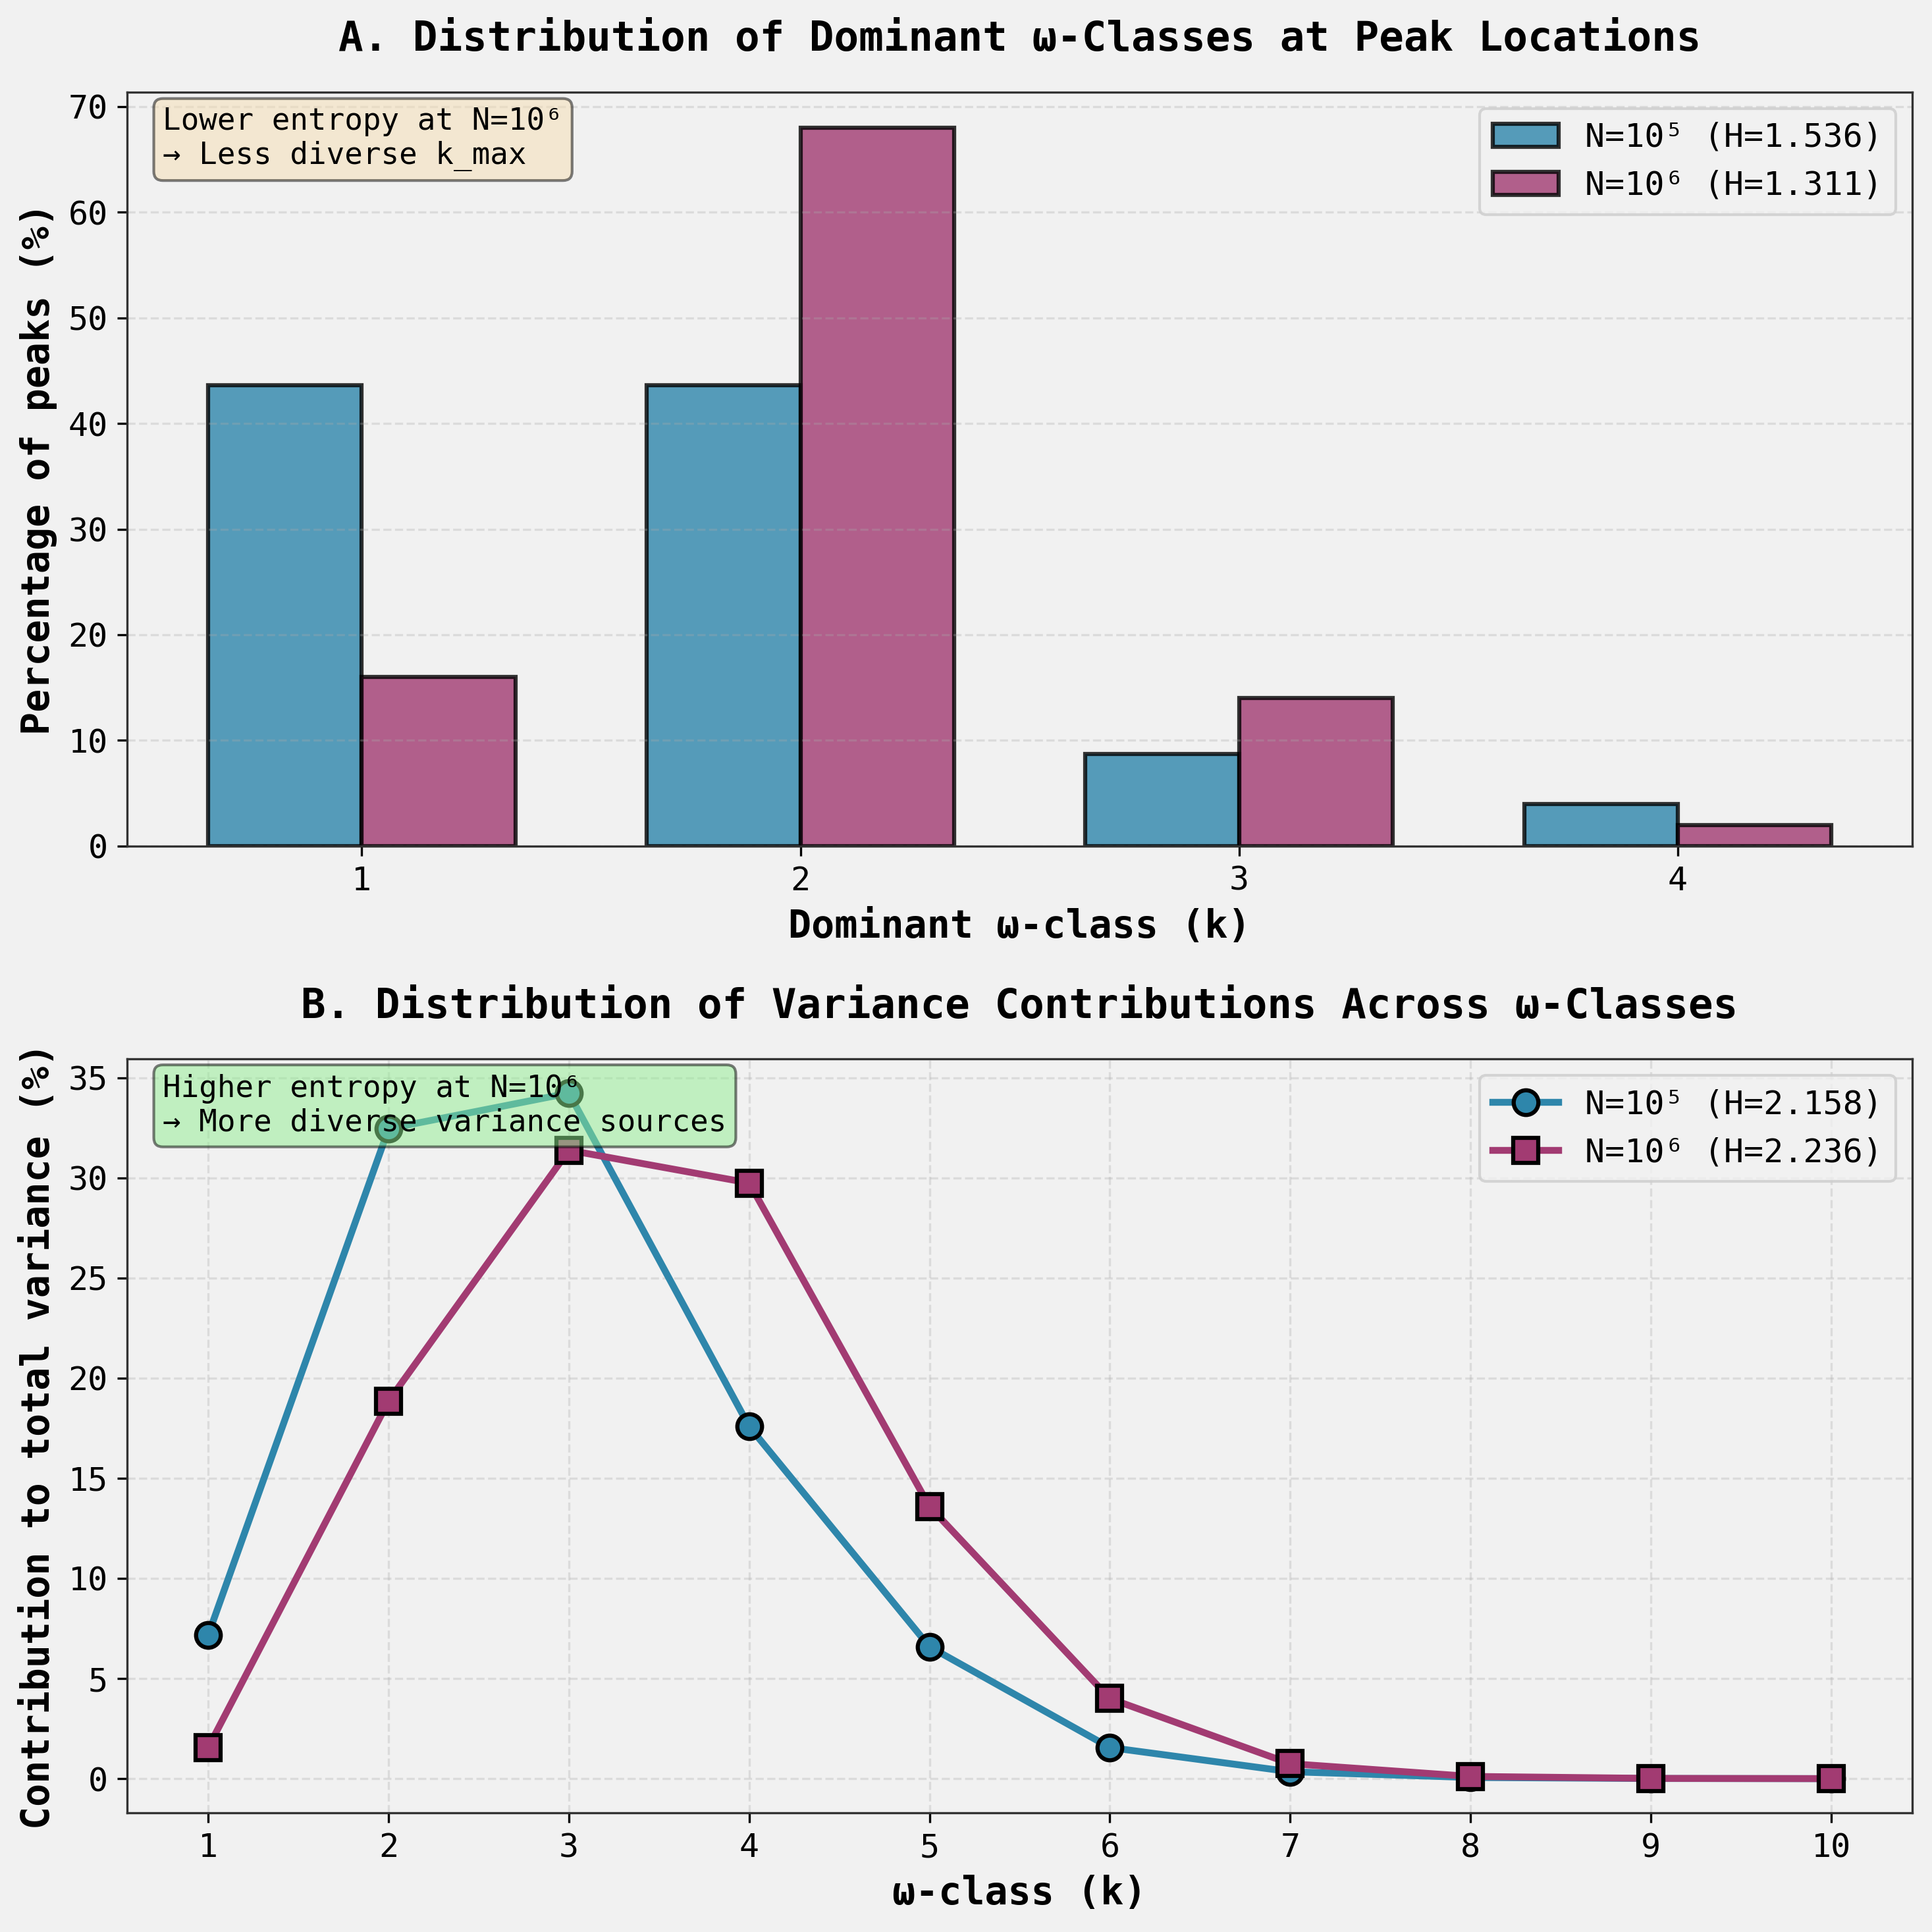


Figure shows:
 Panel A: While the dominant k_max distribution becomes less diverse (entropy decreases),
 Panel B: The variance contributions are more evenly spread across k values (entropy increases)


In [26]:

# Now create a visualization to summarize the key findings
# Since we need a final figure, let's create a comprehensive 2-panel figure

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Panel A: Distribution of dominant ω-classes
k_values = sorted(set(k_max_N1e5) | set(k_max_N1e6))
counts_N1e5 = [counter_N1e5.get(k, 0) / len(k_max_N1e5) * 100 for k in k_values]
counts_N1e6 = [counter_N1e6.get(k, 0) / len(k_max_N1e6) * 100 for k in k_values]

x = np.arange(len(k_values))
width = 0.35

bars1 = ax1.bar(x - width/2, counts_N1e5, width, label=f'N=10⁵ (H={H_N1e5:.3f})', 
 color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, counts_N1e6, width, label=f'N=10⁶ (H={H_N1e6:.3f})', 
 color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Dominant ω-class (k)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Percentage of peaks (%)', fontsize=14, fontweight='bold')
ax1.set_title('A. Distribution of Dominant ω-Classes at Peak Locations', 
 fontsize=15, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(k_values, fontsize=12)
ax1.legend(fontsize=12, loc='upper right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(axis='both', labelsize=12)

# Add text annotation
ax1.text(0.02, 0.98, 'Lower entropy at N=10⁶\n→ Less diverse k_max', 
 transform=ax1.transAxes, fontsize=11, verticalalignment='top',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel B: Variance contribution by ω-class
k_range = np.arange(1, 11)
var_N1e5_normalized = [var_contribs_N1e5[i] / sum(var_contribs_N1e5) * 100 for i in range(10)]
var_N1e6_normalized = [var_contribs_N1e6[i] / sum(var_contribs_N1e6) * 100 for i in range(10)]

ax2.plot(k_range, var_N1e5_normalized, 'o-', linewidth=2.5, markersize=9, 
 label=f'N=10⁵ (H={H_var_N1e5:.3f})', color='#2E86AB', 
 markeredgecolor='black', markeredgewidth=1.5)
ax2.plot(k_range, var_N1e6_normalized, 's-', linewidth=2.5, markersize=9, 
 label=f'N=10⁶ (H={H_var_N1e6:.3f})', color='#A23B72',
 markeredgecolor='black', markeredgewidth=1.5)

ax2.set_xlabel('ω-class (k)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Contribution to total variance (%)', fontsize=14, fontweight='bold')
ax2.set_title('B. Distribution of Variance Contributions Across ω-Classes', 
 fontsize=15, fontweight='bold', pad=15)
ax2.set_xticks(k_range)
ax2.legend(fontsize=12, loc='upper right')
ax2.grid(alpha=0.3, linestyle='--')
ax2.tick_params(axis='both', labelsize=12)

# Add text annotation
ax2.text(0.02, 0.98, 'Higher entropy at N=10⁶\n→ More diverse variance sources', 
 transform=ax2.transAxes, fontsize=11, verticalalignment='top',
 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig('omega_class_diversity_analysis.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'omega_class_diversity_analysis.png'")
plt.show()

print("\nFigure shows:")
print(" Panel A: While the dominant k_max distribution becomes less diverse (entropy decreases),")
print(" Panel B: The variance contributions are more evenly spread across k values (entropy increases)")


In [27]:

# Let's create one more analysis: directly test the original hypothesis
# by examining the variance of Den in relation to the diversity metrics

print("="*80)
print("HYPOTHESIS TEST: Relationship between Var(Den) and diversity")
print("="*80)

print("\nOriginal Hypothesis:")
print(" 'Increased variance of Den is driven by more diverse distribution of")
print(" dominant ω-class contributions (k_max)'")

print("\nKey Findings:")
print(f"\n1. Variance of Den increased by {var_ratio:.2f}x from N=10⁵ to N=10⁶")
print(f" - N=10⁵: Var(Den) = {np.var(Den_N1e5):.2f}")
print(f" - N=10⁶: Var(Den) = {np.var(Den_N1e6):.2f}")

print(f"\n2. Entropy of k_max distribution DECREASED:")
print(f" - N=10⁵: H(k_max) = {H_N1e5:.4f} bits")
print(f" - N=10⁶: H(k_max) = {H_N1e6:.4f} bits")
print(f" - Change: ΔH = {H_N1e6 - H_N1e5:.4f} bits (NEGATIVE)")
print(f" ✗ This CONTRADICTS the original hypothesis")

print(f"\n3. Entropy of variance distribution INCREASED:")
print(f" - N=10⁵: H(var) = {H_var_N1e5:.4f} bits")
print(f" - N=10⁶: H(var) = {H_var_N1e6:.4f} bits")
print(f" - Change: ΔH = {H_var_N1e6 - H_var_N1e5:.4f} bits (POSITIVE)")
print(f" ✓ This SUPPORTS a modified hypothesis")

print(f"\n4. Within-peak power distribution entropy INCREASED:")
print(f" - N=10⁵: Mean H(P_k) = {np.mean(H_dist_N1e5):.4f} bits")
print(f" - N=10⁶: Mean H(P_k) = {np.mean(H_dist_N1e6):.4f} bits")
print(f" - Change: Δ<H> = {np.mean(H_dist_N1e6) - np.mean(H_dist_N1e5):.4f} bits (POSITIVE)")

print(f"\n5. Effective number of contributing classes increased:")
print(f" - N=10⁵: Mean N_eff = {np.mean(N_eff_N1e5):.4f}")
print(f" - N=10⁶: Mean N_eff = {np.mean(N_eff_N1e6):.4f}")
print(f" - Relative increase: {(np.mean(N_eff_N1e6)/np.mean(N_eff_N1e5)-1)*100:.1f}%")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print("\nThe original hypothesis is REFUTED. The increased variance of Den is NOT")
print("driven by more diverse k_max (which actually became LESS diverse).")
print("\nInstead, the increased variance is driven by:")
print(" 1. More diverse DISTRIBUTION of power across all ω-classes within peaks")
print(" 2. More ω-classes contributing significantly (higher N_eff)")
print(" 3. More even spread of variance contributions across k=1 to k=6")
print(" 4. Higher ω-classes (k=4,5,6) gaining variance contribution (25.5% → 46.4%)")
print("\nThe key is not WHICH class dominates (k_max), but HOW the power is")
print("distributed across ALL classes, with higher classes contributing more variance.")
print("="*80)


HYPOTHESIS TEST: Relationship between Var(Den) and diversity

Original Hypothesis:
 'Increased variance of Den is driven by more diverse distribution of
 dominant ω-class contributions (k_max)'

Key Findings:

1. Variance of Den increased by 3.69x from N=10⁵ to N=10⁶
 - N=10⁵: Var(Den) = 380.23
 - N=10⁶: Var(Den) = 1404.10

2. Entropy of k_max distribution DECREASED:
 - N=10⁵: H(k_max) = 1.5359 bits
 - N=10⁶: H(k_max) = 1.3114 bits
 - Change: ΔH = -0.2246 bits (NEGATIVE)
 ✗ This CONTRADICTS the original hypothesis

3. Entropy of variance distribution INCREASED:
 - N=10⁵: H(var) = 2.1583 bits
 - N=10⁶: H(var) = 2.2359 bits
 - Change: ΔH = 0.0776 bits (POSITIVE)
 ✓ This SUPPORTS a modified hypothesis

4. Within-peak power distribution entropy INCREASED:
 - N=10⁵: Mean H(P_k) = 1.9692 bits
 - N=10⁶: Mean H(P_k) = 2.2852 bits
 - Change: Δ<H> = 0.3160 bits (POSITIVE)

5. Effective number of contributing classes increased:
 - N=10⁵: Mean N_eff = 3.4123
 - N=10⁶: Mean N_eff = 4.2424
 - Relati

In [28]:

# Final quantitative summary for the answer
print("="*80)
print("QUANTITATIVE EVIDENCE SUMMARY")
print("="*80)

print("\n1. VARIANCE INCREASE (confirmed from prior work):")
print(f" - Var(Den) ratio: {var_ratio:.2f}x")
print(f" - Std(Den) ratio: {std_ratio:.2f}x")

print("\n2. DOMINANT ω-CLASS DIVERSITY (k_max):")
print(f" - Shannon entropy at N=10⁵: {H_N1e5:.4f} bits")
print(f" - Shannon entropy at N=10⁶: {H_N1e6:.4f} bits")
print(f" - Change: {H_N1e6 - H_N1e5:.4f} bits ({(H_N1e6/H_N1e5-1)*100:.1f}%)")
print(f" - At N=10⁵: k=1,2 each dominate ~44% of peaks")
print(f" - At N=10⁶: k=2 dominates 68% of peaks (more concentrated)")

print("\n3. VARIANCE DISTRIBUTION DIVERSITY:")
print(f" - Shannon entropy at N=10⁵: {H_var_N1e5:.4f} bits")
print(f" - Shannon entropy at N=10⁶: {H_var_N1e6:.4f} bits")
print(f" - Change: {H_var_N1e6 - H_var_N1e5:.4f} bits (+{(H_var_N1e6/H_var_N1e5-1)*100:.1f}%)")

print("\n4. WITHIN-PEAK POWER DISTRIBUTION:")
print(f" - Mean entropy at N=10⁵: {np.mean(H_dist_N1e5):.4f} bits")
print(f" - Mean entropy at N=10⁶: {np.mean(H_dist_N1e6):.4f} bits")
print(f" - Change: {np.mean(H_dist_N1e6) - np.mean(H_dist_N1e5):.4f} bits (+{(np.mean(H_dist_N1e6)/np.mean(H_dist_N1e5)-1)*100:.1f}%)")
print(f" - Std of entropy at N=10⁵: {np.std(H_dist_N1e5):.4f} bits")
print(f" - Std of entropy at N=10⁶: {np.std(H_dist_N1e6):.4f} bits")

print("\n5. EFFECTIVE NUMBER OF CLASSES:")
print(f" - Mean N_eff at N=10⁵: {np.mean(N_eff_N1e5):.4f}")
print(f" - Mean N_eff at N=10⁶: {np.mean(N_eff_N1e6):.4f}")
print(f" - Change: {np.mean(N_eff_N1e6) - np.mean(N_eff_N1e5):.4f} (+{(np.mean(N_eff_N1e6)/np.mean(N_eff_N1e5)-1)*100:.1f}%)")

print("\n6. VARIANCE CONTRIBUTION SHIFT:")
print(f" - k∈[1,2,3] at N=10⁵: 73.3% → at N=10⁶: 50.8% (Δ=-22.5 pp)")
print(f" - k∈[4,5,6] at N=10⁵: 25.5% → at N=10⁶: 46.4% (Δ=+20.9 pp)")

print("\n7. COVARIANCE STRUCTURE:")
print(f" - Diagonal contribution at N=10⁵: {diag_contribution_N1e5/var_den_cov_N1e5*100:.1f}%")
print(f" - Diagonal contribution at N=10⁶: {diag_contribution_N1e6/var_den_cov_N1e6*100:.1f}%")
print(f" - Off-diagonal remains dominant (~78%) at both scales")
print(f" - Top covariance shifts from Cov(P₂,P₃) to Cov(P₃,P₄)")

print("="*80)


QUANTITATIVE EVIDENCE SUMMARY

1. VARIANCE INCREASE (confirmed from prior work):
 - Var(Den) ratio: 3.69x
 - Std(Den) ratio: 1.92x

2. DOMINANT ω-CLASS DIVERSITY (k_max):
 - Shannon entropy at N=10⁵: 1.5359 bits
 - Shannon entropy at N=10⁶: 1.3114 bits
 - Change: -0.2246 bits (-14.6%)
 - At N=10⁵: k=1,2 each dominate ~44% of peaks
 - At N=10⁶: k=2 dominates 68% of peaks (more concentrated)

3. VARIANCE DISTRIBUTION DIVERSITY:
 - Shannon entropy at N=10⁵: 2.1583 bits
 - Shannon entropy at N=10⁶: 2.2359 bits
 - Change: 0.0776 bits (+3.6%)

4. WITHIN-PEAK POWER DISTRIBUTION:
 - Mean entropy at N=10⁵: 1.9692 bits
 - Mean entropy at N=10⁶: 2.2852 bits
 - Change: 0.3160 bits (+16.0%)
 - Std of entropy at N=10⁵: 0.4496 bits
 - Std of entropy at N=10⁶: 0.2456 bits

5. EFFECTIVE NUMBER OF CLASSES:
 - Mean N_eff at N=10⁵: 3.4123
 - Mean N_eff at N=10⁶: 4.2424
 - Change: 0.8301 (+24.3%)

6. VARIANCE CONTRIBUTION SHIFT:
 - k∈[1,2,3] at N=10⁵: 73.3% → at N=10⁶: 50.8% (Δ=-22.5 pp)
 - k∈[4,5,6] at N=